# 01 — Esplorazione del dataset e RFM

## Obiettivi didattici

1. Conoscere lo schema delle 5 tabelle (events, users, products, categories, promotions).
2. Distribuzione temporale degli eventi e definizione di `as_of_date`.
3. Calcolo del RFM base (Recency, Frequency, Monetary) per utente.
4. Distinzione fra utenti che hanno acquistato e "cold users" (solo view).


In [1]:
import sys; sys.path.insert(0, '../src')
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid'); plt.rcParams['figure.dpi'] = 110
from ecom_clustering.data import load_raw, filter_events_until
from ecom_clustering.rfm import compute_rfm
from ecom_clustering.config import DEFAULT_CONFIG


In [2]:
ecom = load_raw()
print(ecom.summary())
print(f'\nTipi azione (eventi): {ecom.events.action.value_counts().to_dict()}')

events=500,000 | users=1,200 | products=3,500 | categories=15 | promotions=365 giorni
period: 2024-01-02 12:27:21+00:00 → 2024-11-22 22:25:56+00:00

Tipi azione (eventi): {'view': 462130, 'add_to_cart': 31701, 'purchase': 6169}


## Distribuzione temporale degli eventi

Verifichiamo che gli eventi siano distribuiti su tutto il periodo (no buchi).

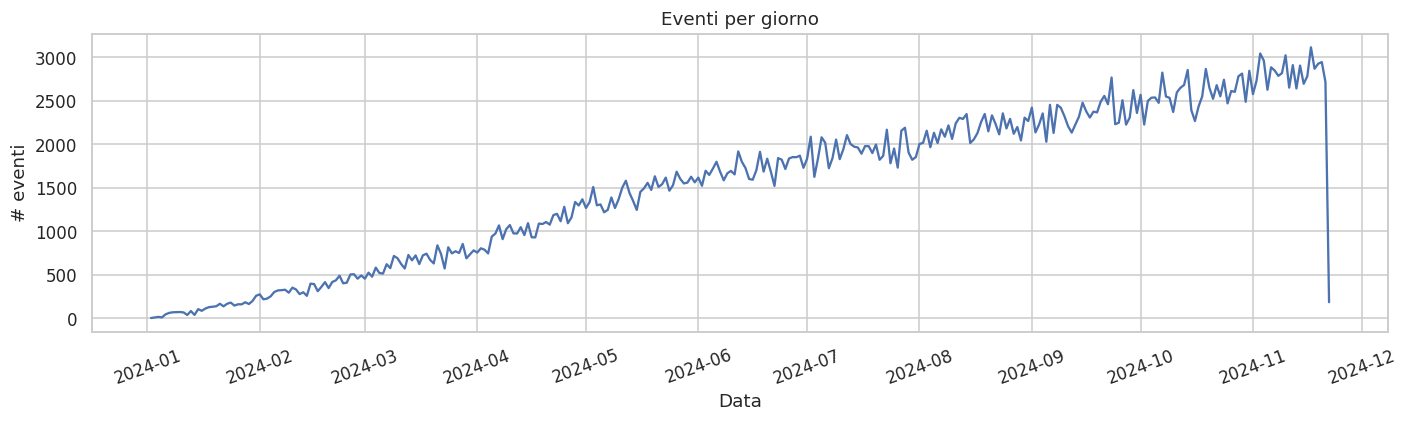

In [3]:
daily_counts = ecom.events.set_index('timestamp').resample('D').size()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily_counts.index, daily_counts.values)
ax.set(title='Eventi per giorno', xlabel='Data', ylabel='# eventi')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout(); plt.show()

## Snapshot temporale e RFM

Scegliamo `as_of` = 30 giorni prima della fine del dataset. Calcoliamo il RFM su tutti gli eventi precedenti.

In [4]:
as_of = ecom.time_max - pd.Timedelta(days=30)
events_history = filter_events_until(ecom.events, as_of)
print(f'as_of = {as_of}')
print(f'Eventi storici: {len(events_history):,} ({len(events_history)/len(ecom.events):.1%})')
rfm = compute_rfm(events_history, as_of, user_universe=ecom.users.user_id)
rfm.head(10)

as_of = 2024-10-23 22:25:56+00:00
Eventi storici: 418,889 (83.8%)


,recency_days,frequency,monetary,has_purchased
user_id,,,,
1,NaN,0,0.00,0
2,120.599201,1,97.59,1
3,NaN,0,0.00,0
4,NaN,0,0.00,0
5,1.549410,27,1234.07,1
6,78.264144,1,28.61,1
7,NaN,0,0.00,0
8,24.219028,6,329.38,1
9,6.356076,1,12.93,1


## Distribuzioni RFM

Le distribuzioni sono spesso skewed (long tail). Visualizzazione log-scale aiuta.

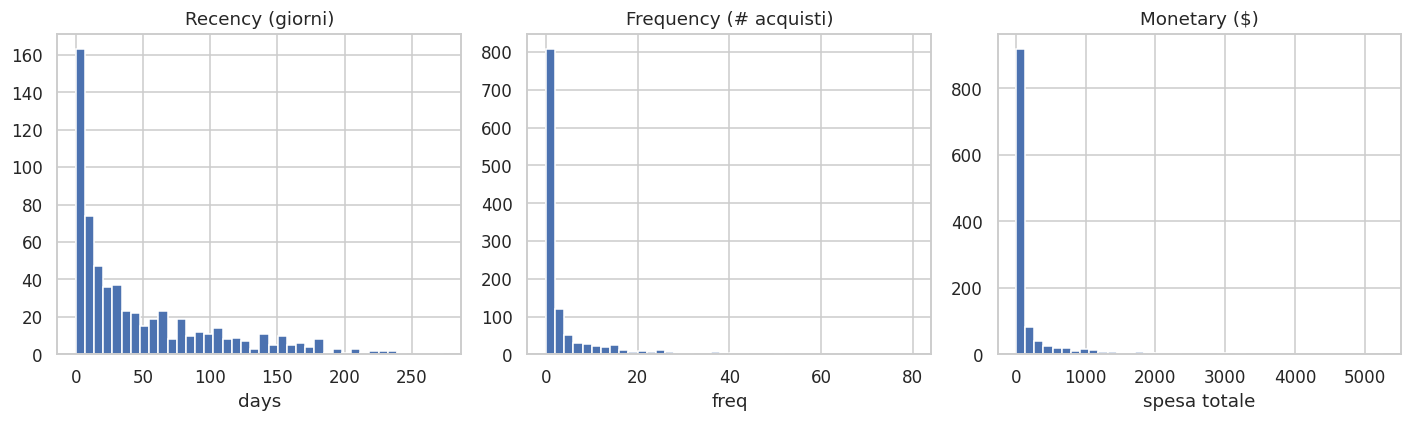

Utenti con almeno 1 acquisto: 628/1200 (52.3%)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].hist(rfm.recency_days.dropna(), bins=40)
axes[0].set(title='Recency (giorni)', xlabel='days')
axes[1].hist(rfm.frequency, bins=40)
axes[1].set(title='Frequency (# acquisti)', xlabel='freq')
axes[2].hist(rfm.monetary, bins=40)
axes[2].set(title='Monetary ($)', xlabel='spesa totale')
fig.tight_layout(); plt.show()
print(f'Utenti con almeno 1 acquisto: {int(rfm.has_purchased.sum())}/{len(rfm)} ({rfm.has_purchased.mean():.1%})')

## Conclusione

- Il dataset copre ~10 mesi (gen → nov 2024).
- Distribuzioni skewed di Frequency/Monetary → utili `log1p` o feature ratio.
- ~46% degli utenti ha almeno 1 acquisto entro `as_of`. I cold users vanno trattati esplicitamente (recency imputata, `has_purchased=0`).
